# Empirical Fisher and Fisher-Weighted k-Means

This notebook continues [Understanding_Granite.ipynb](Understanding_Granite.ipynb) and prototypes the core of [ADR 0003](../docs/adr/0003-fisher-weighted-kmeans-methodology.md) on real Granite weights:

1. **Calibration data.** Sample 100 sequences of 512 tokens from one C4 training shard, following ADR 0002's sampling rule.
2. **Empirical Fisher.** Accumulate squared per-sequence gradients for all 168 quantizable linears, and look at where the sensitivity sits.
3. **The 3-bit seed.** Fit weighted k-means with Lloyd's algorithm on a few hand-picked rows, and compare the codebook with unweighted k-means and uniform round-to-nearest.
4. **Incremental upscaling.** Split every cluster exactly, from 3 to 8 bits, and check the nested-index property.
5. **Error versus bit-width.** Compare incremental upscaling with standalone k-means and round-to-nearest, first on the chosen rows and then on two whole modules.
6. **Initialization ablation.** Show why ADR 0003 uses weighted k-means++ rather than a deterministic quantile initialization.

Per ADR 0001, the functions defined here are prototypes. Once they stabilise they move into `src/anyprec` with tests, and this notebook will import them from there.

## 1. Setup

The constants restate ADR 0002 (checkpoint, module pattern, calibration source) and ADR 0003 (calibration size, bit-widths, Lloyd iteration cap, empty-segment threshold). `load_granite` and `quantizable_linears` are copied from the first notebook, and they are the first candidates for `src/anyprec/models`.

In [1]:
import math
import re
import time
from collections.abc import Callable
from dataclasses import dataclass
from itertools import pairwise
from typing import Literal

import matplotlib.pyplot as plt
import torch
from datasets import Dataset, load_dataset
from tabulate import tabulate
from torch import nn
from torch.utils.hooks import RemovableHandle
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    PreTrainedModel,
    PreTrainedTokenizerBase,
)

# Checkpoint and quantizable-module pattern, as in ADR 0002.

MODEL_ID: str = "ibm-granite/granite-4.0-350m"
REVISION: str = "main"
SEED: int = 0
QUANTIZABLE_PATTERN: re.Pattern[str] = re.compile(
    r"^model\.layers\.\d+\.(self_attn\.(q|k|v|o)_proj|shared_mlp\.(input|output)_linear)$"
)
EXPECTED_QUANTIZABLE: int = 168

# Calibration source and size, as in ADR 0002 and ADR 0003.

C4_PATH: str = "allenai/c4"
C4_FILES: dict[str, str] = {"train": "en/c4-train.00000-of-01024.json.gz"}
NUM_SEQUENCES: int = 100
SEQ_LEN: int = 512

# Quantizer defaults from ADR 0003, Section 7.

SEED_BITS: int = 3
PARENT_BITS: int = 8
LLOYD_MAX_ITER: int = 50
EMPTY_EPS: float = 1e-12
KMEANS_SEED: int = 0

torch.manual_seed(SEED)
DEVICE: torch.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"torch {torch.__version__} | device {DEVICE}")

torch 2.9.1+cu126 | device cuda


In [2]:
def load_granite(
    model_id: str,
    revision: str,
    dtype: torch.dtype,
    device: torch.device,
) -> tuple[PreTrainedTokenizerBase, PreTrainedModel]:
    """Load the Granite tokenizer and causal-LM weights in inference mode.

    :param model_id: Hugging Face Hub repository identifier.
    :param revision: Git revision (branch, tag, or commit) of the repository.
    :param dtype: Floating-point dtype for the model parameters.
    :param device: Device on which the parameters are placed.
    :return: The tokenizer and the model with dropout disabled.
    """
    tokenizer = AutoTokenizer.from_pretrained(model_id, revision=revision)
    model = AutoModelForCausalLM.from_pretrained(
        model_id, revision=revision, dtype=dtype, device_map=str(device)
    )
    model.eval()
    return tokenizer, model


def quantizable_linears(model: nn.Module, pattern: re.Pattern[str]) -> dict[str, nn.Linear]:
    """Collect the linear layers whose qualified names match the quantization pattern.

    :param model: Model whose submodules are searched.
    :param pattern: Compiled regex matched against fully qualified module names.
    :return: Mapping from qualified module name to the matching linear layer.
    """
    return {
        name: module
        for name, module in model.named_modules()
        if isinstance(module, nn.Linear) and pattern.match(name)
    }


tokenizer, model = load_granite(MODEL_ID, REVISION, torch.bfloat16, DEVICE)
targets: dict[str, nn.Linear] = quantizable_linears(model, QUANTIZABLE_PATTERN)
assert len(targets) == EXPECTED_QUANTIZABLE, f"found {len(targets)} targets"
kinds: list[str] = list(dict.fromkeys(name.split(".", 3)[-1] for name in targets))
print(f"{type(model).__name__}: {len(targets)} quantizable linears across {len(kinds)} kinds")

Loading weights:   0%|          | 0/226 [00:00<?, ?it/s]

GraniteMoeHybridForCausalLM: 168 quantizable linears across 6 kinds


## 2. Calibration data

ADR 0002 fixes the sampling rule from the reference implementation. Documents are drawn uniformly at random without replacement using a seeded generator. Each is tokenized as raw text with no BOS, EOS, or chat template, documents shorter than 512 tokens are skipped, and the first 512 tokens of each accepted document are kept. The C4 shard is roughly 300 MB and is cached by `datasets` after the first download.

In [3]:
def sample_calibration(
    documents: Dataset,
    tokenizer: PreTrainedTokenizerBase,
    num_sequences: int,
    seq_len: int,
    seed: int,
) -> tuple[torch.Tensor, int]:
    """Sample fixed-length calibration sequences following the ADR 0002 rule.

    :param documents: Dataset with a ``text`` column.
    :param tokenizer: Tokenizer of the model being calibrated.
    :param num_sequences: Number of sequences to return.
    :param seq_len: Number of tokens per sequence.
    :param seed: Seed of the document permutation.
    :return: Token ids of shape ``[num_sequences, seq_len]`` and the number of documents examined.
    :raises ValueError: If the dataset has too few documents of at least ``seq_len`` tokens.
    """
    # A seeded permutation draws documents uniformly without replacement, reproducibly.

    permutation: list[int] = torch.randperm(
        len(documents), generator=torch.Generator().manual_seed(seed)
    ).tolist()
    accepted: list[torch.Tensor] = []
    examined: int = 0
    for index in permutation:
        examined += 1

        # Raw text without special tokens, so calibration matches the reference implementation.

        ids: list[int] = tokenizer(documents[index]["text"], add_special_tokens=False)["input_ids"]
        if len(ids) < seq_len:
            continue
        accepted.append(torch.tensor(ids[:seq_len], dtype=torch.long))
        if len(accepted) == num_sequences:
            break
    if len(accepted) < num_sequences:
        raise ValueError(f"only {len(accepted)} documents have at least {seq_len} tokens")

    # num_sequences x [seq_len] -> [num_sequences, seq_len]

    return torch.stack(accepted), examined


c4: Dataset = load_dataset(C4_PATH, data_files=C4_FILES, split="train")
calibration, examined = sample_calibration(c4, tokenizer, NUM_SEQUENCES, SEQ_LEN, SEED)
print(f"C4 shard: {len(c4):,} documents; examined {examined} to accept {NUM_SEQUENCES}")
print(f"calibration tokens: {tuple(calibration.shape)}")
print(repr(tokenizer.decode(calibration[0, :48])))

C4 shard: 356,317 documents; examined 383 to accept 100
calibration tokens: (100, 512)
'Since tech businesses have numerous functionalities, it’s not exactly wise to categorize them all into one batch when it comes to WordPress themes. However, that’s why so many theme developers have put together solutions that allow for the ultimate customization. Looking'


## 3. The empirical Fisher diagonal

ADR 0003 approximates the KL divergence between the original and the quantized model by $\tfrac12 \delta^\top F \delta$, and replaces $F$ with the diagonal of the empirical Fisher. Let $\ell_i$ be the mean token negative log-likelihood of calibration sequence $i$, which is exactly the `loss` returned by `model(input_ids=x, labels=x)` (discussed in the first notebook). Then

$$
\hat F_{jj} = \sum_{i=1}^{N} \left(\frac{\partial \ell_i}{\partial \theta_j}\right)^2 .
$$

Two implementation details follow from this formula:

- **One sequence per backward pass.** The gradient must be squared *before* it is summed over sequences. A batch of 100 would return $\big(\sum_i \partial\ell_i/\partial\theta_j\big)^2$, which includes cross terms between sequences.
- **Square inside a hook.** `register_post_accumulate_grad_hook` fires once a weight's `.grad` is complete. The hook adds `grad.float().square()` to a float32 accumulator and then deletes `.grad`, so bfloat16 gradients never accumulate across sequences.

Memory: the model takes about 0.7 GB in bfloat16. The float32 accumulators take $249.6\text{M} \times 4 \text{ bytes} \approx 1.0$ GB. The logits of one 512-token sequence and their gradient take $2 \times 512 \times 100352 \times 4$ bytes, or about 0.4 GB. All of it fits on a 6 GB GPU without gradient checkpointing.

In [4]:
def _make_square_hook(accumulator: torch.Tensor) -> Callable[[torch.Tensor], None]:
    """Build a post-accumulate-grad hook that adds the squared gradient to an accumulator.

    :param accumulator: Float32 tensor with the parameter's shape, updated in place.
    :return: Hook suitable for ``Tensor.register_post_accumulate_grad_hook``.
    """

    def hook(parameter: torch.Tensor) -> None:
        # Square in float32, then drop .grad so the next sequence starts from zero.
        # [d_out, d_in] -> [d_out, d_in]

        assert parameter.grad is not None
        accumulator.add_(parameter.grad.float().square())
        parameter.grad = None

    return hook


def estimate_fisher(
    model: PreTrainedModel,
    calibration: torch.Tensor,
    targets: dict[str, nn.Linear],
) -> tuple[dict[str, torch.Tensor], torch.Tensor]:
    """Accumulate the empirical Fisher diagonal of the target weights (ADR 0003, Section 6).

    :param model: Causal LM whose ``forward`` returns the mean token NLL when given ``labels``.
    :param calibration: Token ids of shape ``[N, T]``.
    :param targets: Linear layers whose weights receive Fisher accumulators.
    :return: Float32 Fisher diagonals keyed by module name (each with its weight's shape),
        and the per-sequence losses of shape ``[N]``.
    """
    # Freeze everything, then re-enable gradients only on target weights. Activations still
    # carry gradients through the frozen embedding and norms.

    for parameter in model.parameters():
        parameter.requires_grad_(False)
    fisher: dict[str, torch.Tensor] = {}
    handles: list[RemovableHandle] = []
    for name, linear in targets.items():
        linear.weight.requires_grad_(True)
        fisher[name] = torch.zeros_like(linear.weight, dtype=torch.float32)
        handles.append(
            linear.weight.register_post_accumulate_grad_hook(_make_square_hook(fisher[name]))
        )

    # One sequence per backward pass, so each hook call squares exactly one per-sequence gradient.

    losses: torch.Tensor = torch.empty(calibration.shape[0])
    try:
        for i in range(calibration.shape[0]):
            # [1, T] token ids; labels equal the inputs because the model shifts them internally.

            tokens: torch.Tensor = calibration[i : i + 1].to(DEVICE)
            loss: torch.Tensor = model(input_ids=tokens, labels=tokens, use_cache=False).loss
            loss.backward()
            losses[i] = loss.item()
    finally:
        # Restore an inference-only model even if a backward pass fails.

        for handle in handles:
            handle.remove()
        for linear in targets.values():
            linear.weight.requires_grad_(False)
            linear.weight.grad = None
    return fisher, losses


torch.cuda.reset_peak_memory_stats()
started: float = time.perf_counter()
fisher, calibration_losses = estimate_fisher(model, calibration, targets)
elapsed: float = time.perf_counter() - started

accumulator_bytes: int = sum(f.numel() * f.element_size() for f in fisher.values())
print(f"Fisher over {NUM_SEQUENCES} x {SEQ_LEN} tokens in {elapsed:.1f} s")
print(
    f"accumulators: {accumulator_bytes / 2**30:.2f} GiB | peak GPU memory: {torch.cuda.max_memory_allocated() / 2**30:.2f} GiB"
)
print(
    f"calibration NLL: {calibration_losses.mean():.3f} nats/token (perplexity {calibration_losses.mean().exp():.2f})"
)

Fisher over 100 x 512 tokens in 13.4 s
accumulators: 0.93 GiB | peak GPU memory: 2.63 GiB
calibration NLL: 3.224 nats/token (perplexity 25.13)


## 4. Where does the sensitivity live?

The absolute scale of $\hat F$ is arbitrary, because ADR 0003 drops positive constant factors, but ratios are meaningful. Every entry comes from the same loss, so it is fine to compare modules, layers, and weights with each other.

Within a row, only the *relative* Fisher values affect the codebook, because multiplying all $f_j$ by a constant leaves the argmin of $J$ unchanged. Across rows and modules, Fisher mass tells us where quantization error hurts the output distribution most. That is not used for the uniform bit-widths of this reproduction, but it would drive any mixed-precision allocation.

### 4.1 By module kind and layer

module kind                 share of mass (%)    share of params (%)    mean F / model mean
------------------------  -------------------  ---------------------  ---------------------
shared_mlp.input_linear                  16.7                   47.1                   0.35
shared_mlp.output_linear                 33.9                   23.5                   1.44
self_attn.q_proj                         14.0                   11.8                   1.19
self_attn.k_proj                          6.9                    2.9                   2.35
self_attn.v_proj                         24.0                    2.9                   8.17
self_attn.o_proj                          4.6                   11.8                   0.39


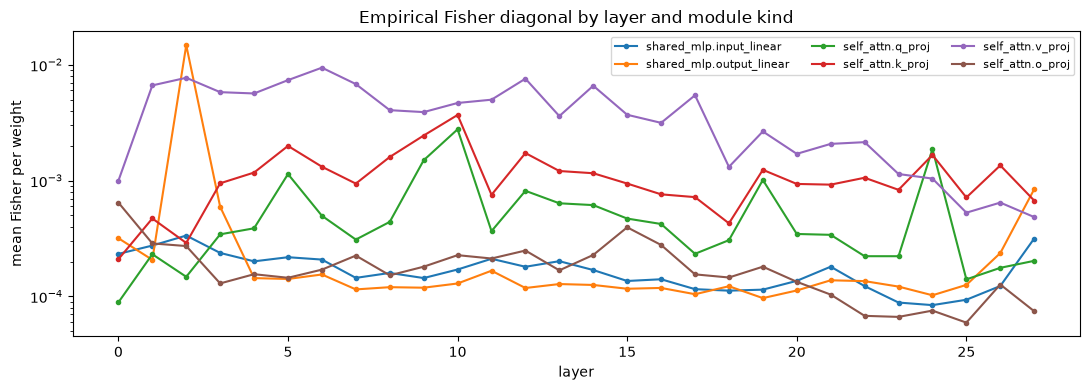

In [5]:
# Accumulate the Fisher mass (sum of entries) of each (layer, kind) pair in float64.
# 168 x [d_out, d_in] -> [num_layers, num_kinds]

num_layers: int = model.config.num_hidden_layers
fisher_mass: torch.Tensor = torch.zeros(num_layers, len(kinds), dtype=torch.float64)
fisher_count: torch.Tensor = torch.zeros(num_layers, len(kinds), dtype=torch.float64)
for name, f in fisher.items():
    layer: int = int(name.split(".")[2])
    kind_index: int = kinds.index(name.split(".", 3)[-1])
    fisher_mass[layer, kind_index] = f.double().sum().item()
    fisher_count[layer, kind_index] = f.numel()

# Share of the total mass and mean Fisher per weight, both per kind: [num_layers, num_kinds] -> [num_kinds].

total_mass: float = fisher_mass.sum().item()
mean_per_weight: torch.Tensor = fisher_mass.sum(dim=0) / fisher_count.sum(dim=0)
reference_mean: float = (total_mass / fisher_count.sum()).item()
kind_rows: list[tuple[str, float, float, float]] = []
for k, kind in enumerate(kinds):
    mass_share: float = 100 * fisher_mass[:, k].sum().item() / total_mass
    param_share: float = 100 * fisher_count[:, k].sum().item() / fisher_count.sum().item()
    kind_rows.append((kind, mass_share, param_share, (mean_per_weight[k] / reference_mean).item()))
print(
    tabulate(
        kind_rows,
        headers=["module kind", "share of mass (%)", "share of params (%)", "mean F / model mean"],
        floatfmt=("", ".1f", ".1f", ".2f"),
    )
)

# Per-layer mean Fisher per weight, one line per kind, on a log scale because it spans decades.

fig, ax = plt.subplots(figsize=(11, 4))
for k, kind in enumerate(kinds):
    ax.plot(
        range(num_layers),
        (fisher_mass[:, k] / fisher_count[:, k]).numpy(),
        marker="o",
        markersize=3,
        label=kind,
    )
ax.set_yscale("log")
ax.set_xlabel("layer")
ax.set_ylabel("mean Fisher per weight")
ax.set_title("Empirical Fisher diagonal by layer and module kind")
ax.legend(fontsize=8, ncol=3)
fig.tight_layout()
plt.show()

### 4.2 How concentrated is the Fisher within a row?

If sensitivity were spread evenly, weighted k-means would behave like unweighted k-means. A simple measure is the share of a row's Fisher mass held by its top 1% of entries: 1% means perfectly even, and values near 100% mean a few weights dominate the objective $J$.

In [6]:
# Per row, the share of Fisher mass in the top 1% of entries: [d_out, d_in] -> [d_out].

top_share_parts: dict[str, list[torch.Tensor]] = {kind: [] for kind in kinds}
for name, f in fisher.items():
    top_k: int = math.ceil(0.01 * f.shape[1])
    share: torch.Tensor = f.topk(top_k, dim=1).values.sum(dim=1) / f.sum(dim=1)
    top_share_parts[name.split(".", 3)[-1]].append(share.cpu())

# Summarize across the 28 layers: 28 x [d_out] -> order statistics over [28 * d_out].

share_rows: list[tuple[str, float, float, float, float]] = []
for kind, parts in top_share_parts.items():
    shares: torch.Tensor = 100 * torch.cat(parts)
    p10, p50, p90 = torch.quantile(shares, torch.tensor([0.1, 0.5, 0.9])).tolist()
    share_rows.append((kind, p50, p10, p90, shares.max().item()))
print("Share of each row's Fisher mass held by its top 1% of entries (1% = perfectly even):")
print(
    tabulate(
        share_rows,
        headers=["module kind", "median (%)", "p10 (%)", "p90 (%)", "max (%)"],
        floatfmt=".1f",
    )
)

Share of each row's Fisher mass held by its top 1% of entries (1% = perfectly even):
module kind                 median (%)    p10 (%)    p90 (%)    max (%)
------------------------  ------------  ---------  ---------  ---------
shared_mlp.input_linear           37.7       24.3       52.4      100.0
shared_mlp.output_linear          14.0        8.9       67.6       99.6
self_attn.q_proj                  83.9       68.1       90.8       97.1
self_attn.k_proj                  77.2       50.8       88.6       96.9
self_attn.v_proj                  91.0       80.7       95.5       98.5
self_attn.o_proj                  19.9       14.4       32.6       75.8


### 4.3 Are the outlier weights also sensitive?

The first notebook found rows whose largest weight sits 20 to 30 RMS units from zero. For each row, we look up the Fisher value of that largest-magnitude weight and compare it with the row's median Fisher value. The percentile rank says where it falls among the row's own sensitivities.

In [7]:
# For every row: crest factor, the column of its largest-magnitude weight, that weight's Fisher value, and its rank.

peak_records: list[tuple[str, int, int]] = []
peak_crest: list[torch.Tensor] = []
peak_ratio: list[torch.Tensor] = []
peak_rank: list[torch.Tensor] = []
peak_share: list[torch.Tensor] = []
peak_column: list[torch.Tensor] = []
with torch.no_grad():
    for name, linear in targets.items():
        weight: torch.Tensor = linear.weight.float()
        f = fisher[name]

        # [d_out, d_in] -> [d_out, 1] column index of each row's largest |w|, then its Fisher value.

        peak_index: torch.Tensor = weight.abs().argmax(dim=1, keepdim=True)
        f_peak: torch.Tensor = f.gather(1, peak_index)

        # Reductions over d_in: [d_out, d_in] -> [d_out] per-row comparisons.

        peak_crest.append((weight.abs().amax(dim=1) / weight.pow(2).mean(dim=1).sqrt()).cpu())
        peak_ratio.append((f_peak.squeeze(1) / f.median(dim=1).values.clamp_min(1e-30)).cpu())
        peak_rank.append((f < f_peak).float().mean(dim=1).cpu())
        peak_share.append((f_peak.squeeze(1) / f.sum(dim=1)).cpu())
        peak_column.append(peak_index.squeeze(1).cpu())
        layer = int(name.split(".")[2])
        peak_records.extend((name.split(".", 3)[-1], layer, row) for row in range(weight.shape[0]))

flat_peak_crest: torch.Tensor = torch.cat(peak_crest)
flat_peak_ratio: torch.Tensor = torch.cat(peak_ratio)
flat_peak_rank: torch.Tensor = torch.cat(peak_rank)
flat_peak_share: torch.Tensor = torch.cat(peak_share)
flat_peak_column: torch.Tensor = torch.cat(peak_column)

# Control group: across all rows, how sensitive is the largest weight typically?

print(
    f"all {flat_peak_ratio.numel():,} rows: median F(peak) / median F(row) = {flat_peak_ratio.median():.1f}, "
    f"median percentile rank = {100 * flat_peak_rank.median():.1f}"
)
print()
peak_table: list[tuple[str, int, int, int, float, float, float, float]] = []
for index in flat_peak_crest.topk(12).indices.tolist():
    kind, layer, row = peak_records[index]
    peak_table.append(
        (
            kind,
            layer,
            row,
            int(flat_peak_column[index]),
            flat_peak_crest[index].item(),
            flat_peak_ratio[index].item(),
            100 * flat_peak_rank[index].item(),
            100 * flat_peak_share[index].item(),
        )
    )
print(
    tabulate(
        peak_table,
        headers=[
            "module kind",
            "layer",
            "row",
            "col",
            "crest",
            "F(peak) / median F",
            "rank (%)",
            "share of row F (%)",
        ],
        floatfmt=("", "", "", "", ".2f", ".1f", ".1f", ".2f"),
    )
)

all 215,040 rows: median F(peak) / median F(row) = 0.9, median percentile rank = 42.6

module kind                 layer    row    col    crest    F(peak) / median F    rank (%)    share of row F (%)
------------------------  -------  -----  -----  -------  --------------------  ----------  --------------------
shared_mlp.output_linear        2    582   1603    31.57                   0.0         0.0                  0.00
shared_mlp.output_linear        2     43   1603    30.30                   0.0         0.0                  0.00
shared_mlp.output_linear       13    505   1857    25.88                   1.9        68.2                  0.03
shared_mlp.input_linear        27   1922    407    25.78                  29.0        98.7                  0.88
shared_mlp.output_linear        2     58    148    25.37                1900.3       100.0                 39.70
shared_mlp.output_linear       26     58   1746    25.15                   3.8        86.5                  0.03
shared_ml

### 4.4 Takeaways from the Fisher

**Calibration loss.** The mean NLL over the 100 calibration sequences is 3.22 nats/token (perplexity 25.1). This is a proper average over 51,100 next-token predictions, unlike the single 23-token sentence in the first notebook (perplexity 74).

**Sensitivity is not proportional to parameter count.** `v_proj` holds 2.9% of the quantized parameters but 24% of the Fisher mass, 8.2 times the model-wide mean per weight. `k_proj` is at 2.35 times. At the other end, `input_linear` holds 47% of the parameters but only 17% of the mass (0.35 times). This reproduction uses one bit-width everywhere, so the imbalance does not change any codebook. It is the obvious lever for a later mixed-precision allocation, though.

**Layer 2's MLP output is the most sensitive module in the model.** Its mean Fisher per weight is about $1.5 \times 10^{-2}$, 25 to 100 times the neighbouring layers, and it is also where most of the extreme-crest rows from the first notebook live.

**Within attention rows, the objective is dominated by a handful of weights.** In `q_proj`, `k_proj`, and `v_proj`, the top 1% of a row's entries (about 10 weights) carry a median 77–91% of its Fisher mass. MLP and `o_proj` rows are much more even (14–38%). The weighted k-means objective $J$ therefore places centroids mainly to serve those few weights. This same concentration breaks the quantile initialization in section 10.

**Outliers come in two kinds, and only the Fisher tells them apart.** Across all rows, the largest-magnitude weight is about as sensitive as a typical weight: the median ratio is 0.9 and the median percentile rank 43. The extreme rows split sharply, though:

- *Large but irrelevant.* Rows 582, 43, and 860 of layer 2 `output_linear` all peak in the same input column, 1603, and that weight's Fisher is essentially zero (percentile rank 0). SwiGLU channel 1603 carries huge outgoing weights but is rarely active on C4, so errors there barely move the loss.
- *Large and critical.* In row 58 of the same module, the peak weight (column 148) alone carries 40% of the row's Fisher mass, 1,927 times the row median. Row 58 recurs as an outlier in layers 3 and 26 through different columns (849 and 1746), and layer 3's column 849 is also the peak of row 517. This is consistent with a few residual-stream channels being written by dedicated MLP channels across depth.

The crest factor and kurtosis cannot distinguish these two cases, and the Fisher can. One caveat: "rarely active" is a statement about C4 text. Chat-formatted prompts could activate channel 1603, which is one reason chat-formatted calibration is listed as future work in ADR 0003.

## 5. Weighted k-means in one dimension

For one row $w \in \mathbb{R}^n$ with sensitivities $f_j = \hat F_{jj}$, ADR 0003 minimizes

$$
J(C, a) = \sum_{j=1}^{n} f_j \left(w_j - C_{a(j)}\right)^2
$$

over a codebook $C$ of $K = 2^b$ centroids and an assignment $a$. The implementation rests on two facts from ADR 0003, Section 2:

- **Contiguity.** After sorting the row, an optimal clustering is a partition into $K$ contiguous segments, and each centroid is its segment's weighted mean.
- **Prefix sums.** With $P^0, P^1, P^2$ the cumulative sums of $f$, $f w$, and $f w^2$ over the sorted row, the half-open segment $[s, e)$ has mass $M = P^0_e - P^0_s$, weighted sum $S$, and weighted square sum $Q$. Its centroid is $\mu = S/M$ and its cost is
$$
\mathrm{cost}(s, e) = Q - \frac{S^2}{M},
$$
both in $O(1)$. The subtraction cancels catastrophically in float32, so it runs in float64.

Every function below is batched over rows, with shapes `[R, n]`. The seed and the upscaling steps then operate only on integer segment borders of shape `[R, K + 1]`.

In [8]:
@dataclass(frozen=True)
class PreparedRows:
    """Sorted rows, their conditioned sensitivities, and float64 prefix sums (ADR 0003, Section 2).

    :param order: Sorting permutation of each row, int64 ``[R, n]``.
    :param w_sorted: Row values in ascending order, float64 ``[R, n]``.
    :param f_sorted: Conditioned sensitivities in the same order, float64 ``[R, n]``.
    :param p0: Prefix sums of ``f`` with a leading zero, float64 ``[R, n + 1]``.
    :param p1: Prefix sums of ``f * w`` with a leading zero, float64 ``[R, n + 1]``.
    :param p2: Prefix sums of ``f * w**2`` with a leading zero, float64 ``[R, n + 1]``.
    """

    order: torch.Tensor
    w_sorted: torch.Tensor
    f_sorted: torch.Tensor
    p0: torch.Tensor
    p1: torch.Tensor
    p2: torch.Tensor


def prepare_rows(weight: torch.Tensor, fisher_rows: torch.Tensor) -> PreparedRows:
    """Condition sensitivities, sort each row, and build the prefix sums.

    :param weight: Rows to quantize, ``[R, n]``.
    :param fisher_rows: Fisher diagonal of the same rows, ``[R, n]``.
    :return: The prepared rows.
    """
    # Zero weights carry no sensitivity; a row with no sensitivity at all falls back to unweighted k-means.

    f: torch.Tensor = fisher_rows.float() * (weight != 0)
    f = torch.where(f.sum(dim=1, keepdim=True) > 0, f, torch.ones_like(f))

    # Sort each row once; every later step works on contiguous segments of this order.
    # [R, n] -> [R, n] permutation, then sorted values and their sensitivities.

    order: torch.Tensor = weight.argsort(dim=1)
    w_sorted: torch.Tensor = weight.gather(1, order).double()
    f_sorted: torch.Tensor = f.gather(1, order).double()

    # [R, n] -> [R, n + 1]: a leading zero makes segment [s, e) equal to P[e] - P[s].

    zero: torch.Tensor = w_sorted.new_zeros(w_sorted.shape[0], 1)
    p0: torch.Tensor = torch.cat([zero, f_sorted.cumsum(dim=1)], dim=1)
    p1: torch.Tensor = torch.cat([zero, (f_sorted * w_sorted).cumsum(dim=1)], dim=1)
    p2: torch.Tensor = torch.cat([zero, (f_sorted * w_sorted * w_sorted).cumsum(dim=1)], dim=1)
    return PreparedRows(order, w_sorted, f_sorted, p0, p1, p2)


def segment_stats(
    rows: PreparedRows, start: torch.Tensor, end: torch.Tensor
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """Compute mass, weighted mean, and weighted squared error of sorted segments ``[start, end)``.

    :param rows: Prepared rows.
    :param start: Inclusive segment starts, int64 ``[R, K]``.
    :param end: Exclusive segment ends, int64 ``[R, K]``.
    :return: Mass, mean, and cost, each float64 ``[R, K]``. Empty or massless segments cost 0.
    """
    # Gather prefix sums at the borders: [R, n + 1] -> [R, K] per statistic.

    mass: torch.Tensor = rows.p0.gather(1, end) - rows.p0.gather(1, start)
    first: torch.Tensor = rows.p1.gather(1, end) - rows.p1.gather(1, start)
    second: torch.Tensor = rows.p2.gather(1, end) - rows.p2.gather(1, start)
    safe_mass: torch.Tensor = mass.clamp_min(EMPTY_EPS)
    mean: torch.Tensor = first / safe_mass

    # Clamping removes the tiny negative round-off that Q - S^2 / M can still produce in float64.

    cost: torch.Tensor = torch.where(
        mass > EMPTY_EPS,
        (second - first * first / safe_mass).clamp_min(0.0),
        torch.zeros_like(mass),
    )
    return mass, mean, cost

### 5.1 The seed: weighted Lloyd's algorithm

Lloyd's algorithm alternates two steps, and both reduce to searches and gathers on the sorted row:

- **Assign.** The interior borders are the sorted positions of the midpoints between adjacent centroids.
- **Update.** Each centroid becomes its segment's weighted mean. An empty segment keeps its previous centroid.

The loop stops when no border moves in any row, or after 50 iterations.

**Initialization** uses weighted greedy k-means++, as `flash1dkmeans` (the reference) and scikit-learn do. Let $D(j)$ be the squared distance from $w_j$ to its nearest chosen centroid. The first centroid is drawn with probability proportional to $f_j$. Each later one is the best of $L = 2 + \lfloor \ln K \rfloor$ candidates drawn with probability proportional to $f_j D(j)$, where "best" means the candidate that leaves the smallest potential $\sum_j f_j D(j)$. A weight that already equals a centroid has $D(j) = 0$ and cannot be drawn again, so centroids never start stacked on top of each other. Sampling uses a seeded `torch.Generator`, which makes the codebooks reproducible.

Two deterministic alternatives are kept for the ablation in section 10:

- `fisher-quantile`: centroid $k$ is the first sorted weight at which the cumulative *sensitivity* reaches $(k + \tfrac12)/K$.
- `count-quantile`: the same rule on the cumulative *count* of weights, ignoring $f$.

In [9]:
InitMethod = Literal["kmeans++", "fisher-quantile", "count-quantile"]


def weighted_kmeanspp_init(
    rows: PreparedRows, num_centroids: int, generator: torch.Generator
) -> torch.Tensor:
    """Initialize centroids with weighted greedy k-means++ (ADR 0003, Section 3).

    :param rows: Prepared rows.
    :param num_centroids: Codebook size ``K``.
    :param generator: Seeded generator on the rows' device.
    :return: Initial centroids, float64 ``[R, K]``, ascending.
    """
    n: int = rows.w_sorted.shape[1]
    local_trials: int = 2 + int(math.log(num_centroids))
    w, f = rows.w_sorted, rows.f_sorted

    # First centroid drawn in proportion to sensitivity: [R, n] -> [R, 1] index -> [R, 1] value.

    chosen: list[torch.Tensor] = [w.gather(1, torch.multinomial(f.float(), 1, generator=generator))]
    nearest: torch.Tensor = (w - chosen[0]).square()
    for _ in range(1, num_centroids):
        # Candidates are drawn in proportion to f * D. Dividing by the row maximum keeps the
        # float32 probabilities that multinomial needs away from underflow.

        potential: torch.Tensor = f * nearest
        potential = torch.where(potential.sum(dim=1, keepdim=True) > 0, potential, f)
        probabilities: torch.Tensor = (potential / potential.amax(dim=1, keepdim=True)).float()
        candidates: torch.Tensor = torch.multinomial(
            probabilities, local_trials, replacement=True, generator=generator
        )
        values: torch.Tensor = w.gather(1, candidates)

        # Nearest-centroid distance if each candidate were added: [R, 1, n] vs [R, L, n] -> [R, L, n].
        # Keep the candidate with the smallest resulting potential: [R, L] -> [R, 1].

        trial: torch.Tensor = torch.minimum(
            nearest[:, None, :], (w[:, None, :] - values[:, :, None]).square()
        )
        best: torch.Tensor = (f[:, None, :] * trial).sum(dim=2).argmin(dim=1, keepdim=True)
        chosen.append(values.gather(1, best))
        nearest = trial.gather(1, best[:, :, None].expand(-1, 1, n)).squeeze(1)

    # K x [R, 1] -> [R, K], ascending so midpoints between neighbours are well defined.

    return torch.cat(chosen, dim=1).sort(dim=1).values


def quantile_init(rows: PreparedRows, num_centroids: int, by_mass: bool) -> torch.Tensor:
    """Initialize centroids at the ``(k + 1/2) / K`` quantiles of sensitivity or of count.

    Used only for the ablation in section 10; ADR 0003 explains why k-means++ is preferred.

    :param rows: Prepared rows.
    :param num_centroids: Codebook size ``K``.
    :param by_mass: Use cumulative Fisher mass if true, cumulative weight count otherwise.
    :return: Initial centroids, float64 ``[R, K]``, ascending.
    """
    num_rows, n = rows.w_sorted.shape

    # Normalized cumulative mass or count at each sorted position: [R, n].

    if by_mass:
        cdf: torch.Tensor = (rows.p0[:, 1:] / rows.p0[:, -1:]).contiguous()
    else:
        cdf = (
            (torch.arange(1, n + 1, device=rows.p0.device, dtype=torch.float64) / n)
            .expand(num_rows, -1)
            .contiguous()
        )

    # Target levels broadcast to [R, K], then the first position reaching each level.

    levels: torch.Tensor = (
        torch.arange(num_centroids, device=cdf.device, dtype=torch.float64) + 0.5
    ) / num_centroids
    positions: torch.Tensor = torch.searchsorted(cdf, levels.expand(num_rows, -1).contiguous())
    return rows.w_sorted.gather(1, positions.clamp_max(n - 1))


def initial_centroids(
    rows: PreparedRows, num_centroids: int, init: InitMethod, seed: int
) -> torch.Tensor:
    """Dispatch to the requested initialization.

    :param rows: Prepared rows.
    :param num_centroids: Codebook size ``K``.
    :param init: Initialization method.
    :param seed: Seed of the k-means++ generator; ignored by the quantile methods.
    :return: Initial centroids, float64 ``[R, K]``.
    """
    if init == "kmeans++":
        generator = torch.Generator(device=rows.w_sorted.device).manual_seed(seed)
        return weighted_kmeanspp_init(rows, num_centroids, generator)
    return quantile_init(rows, num_centroids, by_mass=init == "fisher-quantile")


def weighted_lloyd(
    rows: PreparedRows,
    num_centroids: int,
    init: InitMethod = "kmeans++",
    seed: int = KMEANS_SEED,
    max_iter: int = LLOYD_MAX_ITER,
) -> tuple[torch.Tensor, torch.Tensor, int]:
    """Fit weighted 1-D k-means to every row with Lloyd's algorithm (ADR 0003, Section 3).

    :param rows: Prepared rows.
    :param num_centroids: Codebook size ``K``.
    :param init: Initialization method; ``kmeans++`` is the ADR 0003 default.
    :param seed: Seed of the k-means++ generator.
    :param max_iter: Iteration cap.
    :return: Centroids ``[R, K]`` (float64), segment borders ``[R, K + 1]`` (int64), and the
        number of iterations run.
    """
    num_rows, n = rows.w_sorted.shape
    centroids: torch.Tensor = initial_centroids(rows, num_centroids, init, seed)
    first_border: torch.Tensor = torch.zeros(num_rows, 1, dtype=torch.long, device=centroids.device)
    last_border: torch.Tensor = torch.full(
        (num_rows, 1), n, dtype=torch.long, device=centroids.device
    )
    borders: torch.Tensor | None = None
    iterations: int = 0
    for iteration in range(1, max_iter + 1):
        iterations = iteration

        # Assign: [R, K] centroids -> [R, K - 1] midpoints -> sorted positions -> [R, K + 1] borders.

        midpoints: torch.Tensor = 0.5 * (centroids[:, :-1] + centroids[:, 1:])
        interior: torch.Tensor = torch.searchsorted(rows.w_sorted, midpoints.contiguous())
        new_borders: torch.Tensor = torch.cat([first_border, interior, last_border], dim=1)

        # Converged once no border moves; the centroids are already the means of these segments.

        if borders is not None and torch.equal(new_borders, borders):
            break
        borders = new_borders

        # Update: weighted means of non-empty segments; re-sorting keeps the midpoints monotone.

        mass, mean, _ = segment_stats(rows, borders[:, :-1], borders[:, 1:])
        centroids = torch.where(mass > EMPTY_EPS, mean, centroids).sort(dim=1).values
    assert borders is not None
    return centroids, borders, iterations

### 5.2 Upscaling: the exact two-way split

To go from $b$ to $b+1$ bits, every segment $[s_k, e_k)$ is split at the point $m_k^\star$ that minimizes $\mathrm{cost}(s_k, m) + \mathrm{cost}(m, e_k)$. Parent $k$ gets children $2k$ and $2k+1$, so the new bit is appended as the least significant bit, and $a^{(b)} = a^{(B)} \gg (B - b)$.

The batched version evaluates every interior position $m \in \{1, \dots, n-1\}$ once, charges it to the segment that owns it, and takes a segmented argmin with `scatter_reduce`. That is $O(n)$ per row per step. A segment that cannot be split, because it has fewer than two points, keeps an empty left child, and both children inherit the parent centroid.

In [10]:
def split_all_segments(
    rows: PreparedRows, borders: torch.Tensor, centroids: torch.Tensor
) -> tuple[torch.Tensor, torch.Tensor]:
    """Split every segment at its cost-minimizing point (ADR 0003, Section 4).

    :param rows: Prepared rows.
    :param borders: Segment borders at bit-width ``b``, int64 ``[R, K + 1]``.
    :param centroids: Centroids at bit-width ``b``, float64 ``[R, K]``.
    :return: Centroids ``[R, 2K]`` and borders ``[R, 2K + 1]`` at bit-width ``b + 1``.
    """
    num_rows, n = rows.w_sorted.shape
    num_segments: int = centroids.shape[1]

    # Every interior split point, and the segment that owns it: [n - 1] -> [R, n - 1].

    candidates: torch.Tensor = (
        torch.arange(1, n, device=borders.device).expand(num_rows, -1).contiguous()
    )
    owner: torch.Tensor = torch.searchsorted(borders[:, 1:].contiguous(), candidates, right=True)
    start: torch.Tensor = borders.gather(1, owner)
    end: torch.Tensor = borders.gather(1, owner + 1)

    # Cost of splitting at each candidate; a valid split leaves both children non-empty. [R, n - 1]

    _, _, left_cost = segment_stats(rows, start, candidates)
    _, _, right_cost = segment_stats(rows, candidates, end)
    valid: torch.Tensor = (candidates > start) & (candidates < end)
    total: torch.Tensor = torch.where(valid, left_cost + right_cost, math.inf)

    # Segmented argmin: the minimum per owning segment, then the first candidate attaining it. [R, K]

    best: torch.Tensor = torch.full(
        (num_rows, num_segments), math.inf, dtype=torch.float64, device=borders.device
    )
    best = best.scatter_reduce(1, owner, total, reduce="amin")
    hit: torch.Tensor = total == best.gather(1, owner)
    split: torch.Tensor = torch.full(
        (num_rows, num_segments), n, dtype=torch.long, device=borders.device
    )
    split = split.scatter_reduce(1, owner, torch.where(hit, candidates, n), reduce="amin")
    split = torch.where(best.isfinite(), split, borders[:, :-1])

    # Interleave parent starts with split points: [R, K] x 2 -> [R, 2K] -> [R, 2K + 1] borders.

    child_borders: torch.Tensor = torch.stack([borders[:, :-1], split], dim=2).reshape(
        num_rows, 2 * num_segments
    )
    child_borders = torch.cat([child_borders, borders[:, -1:]], dim=1)

    # Children take their segment means; empty children inherit the parent centroid. [R, 2K]

    mass, mean, _ = segment_stats(rows, child_borders[:, :-1], child_borders[:, 1:])
    parent: torch.Tensor = centroids.repeat_interleave(2, dim=1)
    return torch.where(mass > EMPTY_EPS, mean, parent), child_borders

### 5.3 Drivers, reconstruction, and the round-to-nearest baseline

- `quantize_incremental` runs the 3-bit seed and then five splits, keeping every level's codebook and borders. This is the any-precision parent.
- `quantize_standalone` refits Lloyd from scratch at each bit-width, which is the paper's non-nested baseline.
- `uniform_rtn` is per-row asymmetric min-max round-to-nearest with $2^b$ evenly spaced levels. It is the simplest uniform baseline. Its error is still scored with the Fisher-weighted $J$, so all three methods are compared on the same objective.

In [11]:
Codebook = tuple[torch.Tensor, torch.Tensor]


def quantize_incremental(
    rows: PreparedRows, seed_bits: int, parent_bits: int, init: InitMethod = "kmeans++"
) -> dict[int, Codebook]:
    """Build nested codebooks from a Lloyd seed followed by exact splits.

    :param rows: Prepared rows.
    :param seed_bits: Seed bit-width ``b_0``.
    :param parent_bits: Parent bit-width ``B``.
    :param init: Initialization of the seed.
    :return: ``(centroids, borders)`` for every bit-width from ``seed_bits`` to ``parent_bits``.
    """
    centroids, borders, _ = weighted_lloyd(rows, 2**seed_bits, init)
    levels: dict[int, Codebook] = {seed_bits: (centroids, borders)}
    for bits in range(seed_bits, parent_bits):
        centroids, borders = split_all_segments(rows, borders, centroids)
        levels[bits + 1] = (centroids, borders)
    return levels


def quantize_standalone(
    rows: PreparedRows, seed_bits: int, parent_bits: int, init: InitMethod = "kmeans++"
) -> dict[int, Codebook]:
    """Fit an independent Lloyd codebook at every bit-width (ADR 0003, Section 5).

    :param rows: Prepared rows.
    :param seed_bits: Lowest bit-width.
    :param parent_bits: Highest bit-width.
    :param init: Initialization used at every bit-width.
    :return: ``(centroids, borders)`` for every bit-width from ``seed_bits`` to ``parent_bits``.
    """
    return {
        bits: weighted_lloyd(rows, 2**bits, init)[:2] for bits in range(seed_bits, parent_bits + 1)
    }


def segment_ids(borders: torch.Tensor, n: int) -> torch.Tensor:
    """Map every sorted position to the index of the segment containing it.

    :param borders: Segment borders, int64 ``[R, K + 1]``.
    :param n: Row length.
    :return: Segment index of each sorted position, int64 ``[R, n]``.
    """
    positions: torch.Tensor = (
        torch.arange(n, device=borders.device).expand(borders.shape[0], -1).contiguous()
    )
    return torch.searchsorted(borders[:, 1:].contiguous(), positions, right=True)


def codebook_error(rows: PreparedRows, codebook: Codebook) -> torch.Tensor:
    """Evaluate the Fisher-weighted objective ``J`` of a codebook on every row.

    :param rows: Prepared rows.
    :param codebook: ``(centroids [R, K], borders [R, K + 1])``.
    :return: ``J`` per row, float64 ``[R]``.
    """
    centroids, borders = codebook

    # Look up each sorted position's centroid: [R, K] gathered by [R, n] ids -> [R, n].

    reconstructed: torch.Tensor = centroids.gather(1, segment_ids(borders, rows.w_sorted.shape[1]))
    return (rows.f_sorted * (rows.w_sorted - reconstructed).square()).sum(dim=1)


def uniform_rtn(rows: PreparedRows, bits: int) -> tuple[torch.Tensor, torch.Tensor]:
    """Quantize every row to ``2**bits`` evenly spaced levels between its minimum and maximum.

    :param rows: Prepared rows.
    :param bits: Bit-width.
    :return: Levels ``[R, 2**bits]`` and the Fisher-weighted error ``J`` per row ``[R]``.
    """
    # Row extremes are the first and last sorted values: [R, n] -> [R, 1] each.

    low: torch.Tensor = rows.w_sorted[:, :1]
    step: torch.Tensor = (rows.w_sorted[:, -1:] - low) / (2**bits - 1)
    levels: torch.Tensor = low + step * torch.arange(
        2**bits, device=low.device, dtype=torch.float64
    )
    reconstructed: torch.Tensor = low + torch.round((rows.w_sorted - low) / step) * step
    return levels, (rows.f_sorted * (rows.w_sorted - reconstructed).square()).sum(dim=1)

## 6. Rows to study

Three rows cover the behaviours we care about:

- **Typical.** The row of layer 14's `q_proj` whose crest factor is closest to that module's median, standing in for the near-Gaussian majority.
- **Outlier.** The row with the highest crest factor in the model, which the first notebook located in `shared_mlp.output_linear`.
- **Most sensitive.** The row with the largest total Fisher mass, where quantization error costs the most KL.

In [12]:
@dataclass(frozen=True)
class RowStudy:
    """One weight row selected for detailed study.

    :param label: Short description used in plots and tables.
    :param module: Qualified module name.
    :param row: Row index within the module's weight.
    :param weight: Row values, float32 ``[1, n]``.
    :param fisher_row: Fisher diagonal of the row, float32 ``[1, n]``.
    """

    label: str
    module: str
    row: int
    weight: torch.Tensor
    fisher_row: torch.Tensor


def make_study(label: str, module: str, row: int) -> RowStudy:
    """Slice one row and its Fisher values out of a target module.

    :param label: Short description.
    :param module: Qualified module name.
    :param row: Row index.
    :return: The study record.
    """
    weight: torch.Tensor = targets[module].weight[row : row + 1].float()
    return RowStudy(label, module, row, weight, fisher[module][row : row + 1])


# Typical: the q_proj row of layer 14 whose crest factor is closest to the module median.

typical_module: str = "model.layers.14.self_attn.q_proj"
typical_weight: torch.Tensor = targets[typical_module].weight.float()
typical_crest: torch.Tensor = (
    typical_weight.abs().amax(dim=1) / typical_weight.pow(2).mean(dim=1).sqrt()
)
typical_row: int = int((typical_crest - typical_crest.median()).abs().argmin())

# Outlier and most sensitive rows, located by flat index over every row of every module.

outlier_kind, outlier_layer, outlier_row = peak_records[int(flat_peak_crest.argmax())]
row_mass: torch.Tensor = torch.cat([f.double().sum(dim=1).cpu() for f in fisher.values()])
sensitive_kind, sensitive_layer, sensitive_row = peak_records[int(row_mass.argmax())]

studies: list[RowStudy] = [
    make_study("typical", typical_module, typical_row),
    make_study("outlier", f"model.layers.{outlier_layer}.{outlier_kind}", outlier_row),
    make_study("most sensitive", f"model.layers.{sensitive_layer}.{sensitive_kind}", sensitive_row),
]
study_rows: list[tuple[str, str, int, int, float]] = []
for study in studies:
    w: torch.Tensor = study.weight
    crest: float = (w.abs().max() / w.pow(2).mean().sqrt()).item()
    study_rows.append((study.label, study.module, study.row, w.shape[1], crest))
print(tabulate(study_rows, headers=["study", "module", "row", "n", "crest"], floatfmt=".2f"))

study           module                                     row     n    crest
--------------  ---------------------------------------  -----  ----  -------
typical         model.layers.14.self_attn.q_proj           490  1024     3.75
outlier         model.layers.2.shared_mlp.output_linear    582  2048    31.57
most sensitive  model.layers.24.self_attn.q_proj           510  1024     3.60


## 7. The 3-bit seed

For each row, three 8-level codebooks are compared:

- **Weighted k-means** (solid red lines), the ADR 0003 seed.
- **Unweighted k-means** (dashed gray lines), the same algorithm with $f_j = 1$, which shows what the Fisher weights change.
- **Uniform RTN** (dotted green lines), evenly spaced between the row's minimum and maximum.

The blue histogram counts weights, and the orange step curve shows how the row's Fisher mass is distributed over the same bins. Values are in units of the row's RMS, so the three rows share an axis scale.

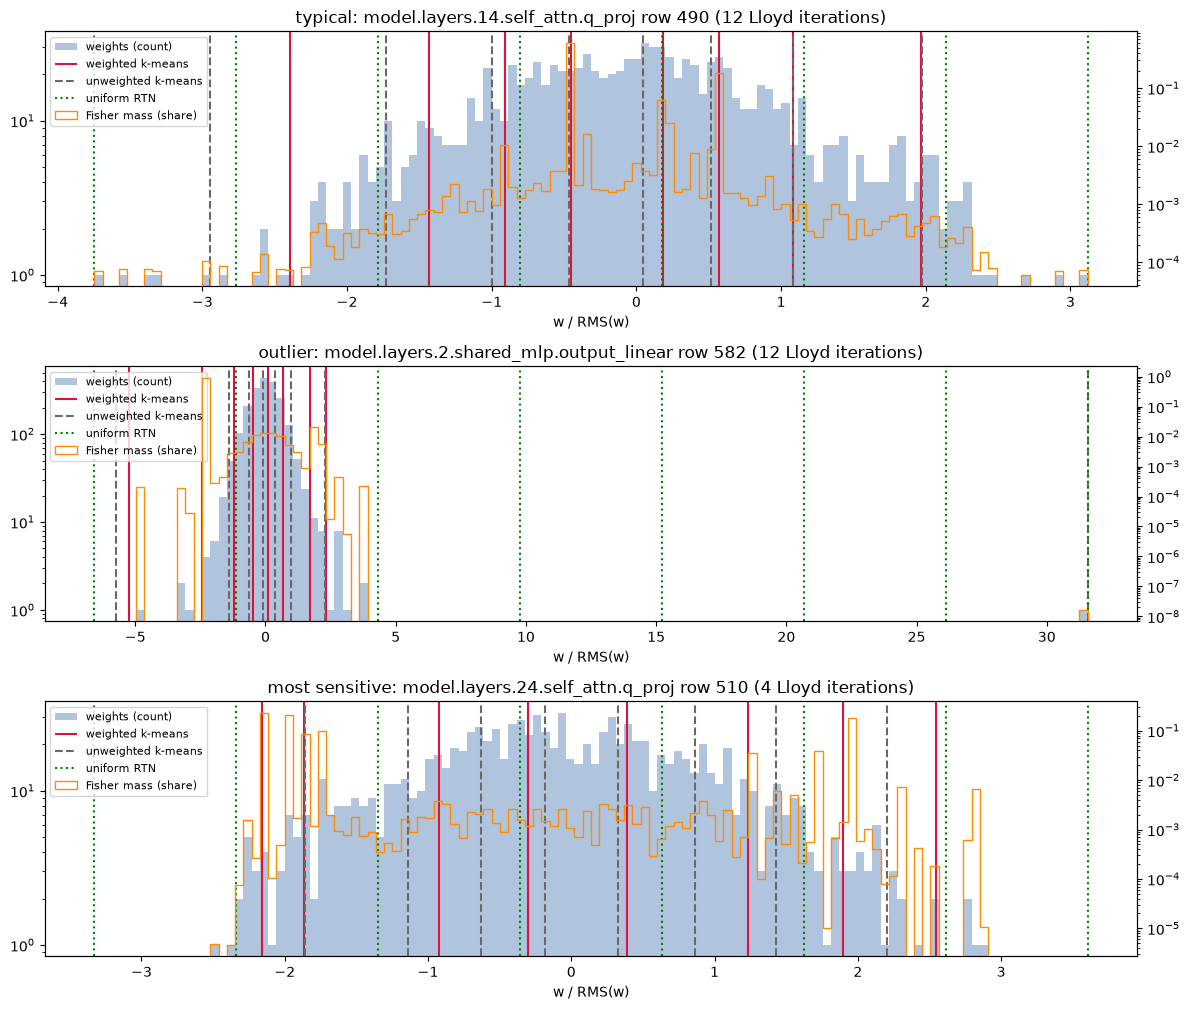

In [13]:
seeds: dict[str, tuple[PreparedRows, torch.Tensor, torch.Tensor]] = {}
fig, axes = plt.subplots(len(studies), 1, figsize=(12, 3.4 * len(studies)))
for ax, study in zip(axes, studies, strict=True):
    rows: PreparedRows = prepare_rows(study.weight, study.fisher_row)
    unweighted: PreparedRows = prepare_rows(study.weight, torch.ones_like(study.fisher_row))

    # Fit the three 8-level codebooks; each is [1, 8].

    centroids, borders, iterations = weighted_lloyd(rows, 2**SEED_BITS)
    plain_centroids, _, _ = weighted_lloyd(unweighted, 2**SEED_BITS)
    rtn_levels, _ = uniform_rtn(rows, SEED_BITS)
    seeds[study.label] = (rows, centroids, borders)

    # Express everything in RMS units: [1, n] -> [n] on the CPU for plotting.

    rms: float = study.weight.pow(2).mean().sqrt().item()
    values = (rows.w_sorted[0] / rms).cpu().numpy()
    bins = torch.linspace(float(values.min()), float(values.max()), 121).numpy()
    ax.hist(values, bins=bins, color="lightsteelblue", log=True, label="weights (count)")
    mass_axis = ax.twinx()
    mass_axis.hist(
        values,
        bins=bins,
        weights=(rows.f_sorted[0] / rows.f_sorted[0].sum()).cpu().numpy(),
        histtype="step",
        color="darkorange",
        log=True,
        label="Fisher mass (share)",
    )

    # Draw each codebook as a single vlines call, so it gets exactly one legend entry.

    for levels, style, color, label in (
        (centroids, "solid", "crimson", "weighted k-means"),
        (plain_centroids, "dashed", "dimgray", "unweighted k-means"),
        (rtn_levels, "dotted", "green", "uniform RTN"),
    ):
        ax.vlines(
            (levels[0] / rms).cpu().numpy(),
            0,
            1,
            transform=ax.get_xaxis_transform(),
            colors=color,
            linestyles=style,
            label=label,
        )
    ax.set_title(f"{study.label}: {study.module} row {study.row} ({iterations} Lloyd iterations)")
    ax.set_xlabel("w / RMS(w)")
    handles_a, labels_a = ax.get_legend_handles_labels()
    handles_b, labels_b = mass_axis.get_legend_handles_labels()
    ax.legend(handles_a + handles_b, labels_a + labels_b, fontsize=8, loc="upper left")
fig.tight_layout()
plt.show()

In [14]:
# Per cluster: members (border differences), Fisher mass share, and centroid in RMS units.

for study in studies:
    rows, centroids, borders = seeds[study.label]
    mass, _, _ = segment_stats(rows, borders[:, :-1], borders[:, 1:])
    rms = study.weight.pow(2).mean().sqrt().item()
    sizes: list[int] = (borders[0, 1:] - borders[0, :-1]).tolist()
    shares: list[float] = (100 * mass[0] / mass[0].sum()).tolist()
    print(f"\n{study.label} ({study.module} row {study.row})")
    print(
        tabulate(
            [
                (k, c / rms, size, share)
                for k, (c, size, share) in enumerate(
                    zip(centroids[0].tolist(), sizes, shares, strict=True)
                )
            ],
            headers=["cluster", "centroid / RMS", "members", "Fisher share (%)"],
            floatfmt=".2f",
        )
    )


typical (model.layers.14.self_attn.q_proj row 490)
  cluster    centroid / RMS    members    Fisher share (%)
---------  ----------------  ---------  ------------------
        0             -2.40         29                0.25
        1             -1.43         90                0.97
        2             -0.91        135                2.13
        3             -0.45        209               63.58
        4              0.18        228               10.71
        5              0.57        147               20.62
        6              1.08        116                1.11
        7              1.97         70                0.64

outlier (model.layers.2.shared_mlp.output_linear row 582)
  cluster    centroid / RMS    members    Fisher share (%)
---------  ----------------  ---------  ------------------
        0             -5.25          2                0.03
        1             -2.42         13               90.37
        2             -1.21        176                0.63
    

#### Takeaways from the seed

- **Typical row.** Weighted and unweighted k-means spread their centroids similarly across the bell curve. The weighted codebook tightens around the regions where the Fisher mass sits: the cluster at $-0.45$ holds 64% of the row's mass with 209 of the 1,024 weights.
- **Outlier row.** This is the crest-factor argument from the first notebook, made visible. Uniform RTN has to stretch its grid to the $+31.6$ RMS weight, so only 2 of its 8 levels land inside the bulk of the row. Unweighted k-means spends a whole centroid on the outlier (the dashed line at 31.5). Weighted k-means does not: the outlier's Fisher share is about $10^{-8}$, so it is absorbed into the top cluster at 2.34 and reconstructed about 29 RMS units off. In exchange, the 13 weights near $-2.4$ that hold 90% of the row's sensitivity get a centroid of their own.
- **Most sensitive row.** The mass concentrates at the tails ($-2.2$, $-1.9$, and $+1.9$ RMS), so four of the eight centroids sit there, and the flat middle of the row shares the rest. Lloyd converged in 4 iterations here, and in 12 for the other two rows.

## 8. Incremental upscaling from 3 to 8 bits

Starting from each seed, five exact splits produce the 4-bit through 8-bit codebooks. ADR 0003, Section 4 lists the properties this construction guarantees, and the cell below checks each one for every studied row:

1. **Nested indices.** $a^{(b)} = a^{(8)} \gg (8 - b)$ for every $b$, so the 8-bit index alone determines every lower precision.
2. **Monotone improvement.** $J^{(b+1)} \le J^{(b)}$.
3. **Sorted codebooks.** Every $C^{(b)}$ is non-decreasing.
4. **Exact seed.** The 3-bit level equals standalone k-means at 3 bits.

In [15]:
incremental: dict[str, dict[int, Codebook]] = {}
standalone: dict[str, dict[int, Codebook]] = {}
bit_widths: list[int] = list(range(SEED_BITS, PARENT_BITS + 1))
property_rows: list[tuple[str, bool, bool, bool, bool]] = []
for study in studies:
    rows = seeds[study.label][0]
    incremental[study.label] = quantize_incremental(rows, SEED_BITS, PARENT_BITS)
    standalone[study.label] = quantize_standalone(rows, SEED_BITS, PARENT_BITS)
    levels = incremental[study.label]
    n: int = rows.w_sorted.shape[1]

    # Property 1: every lower index is the parent index shifted right. [1, n] int64 comparisons.

    parent_ids: torch.Tensor = segment_ids(levels[PARENT_BITS][1], n)
    nested: bool = all(
        torch.equal(segment_ids(levels[b][1], n), parent_ids >> (PARENT_BITS - b))
        for b in bit_widths
    )

    # Properties 2 to 4: monotone J, sorted codebooks, and a seed identical to standalone at b_0.

    errors: list[float] = [codebook_error(rows, levels[b]).item() for b in bit_widths]
    monotone: bool = all(later <= earlier * (1 + 1e-12) for earlier, later in pairwise(errors))
    ordered: bool = all(bool((levels[b][0].diff(dim=1) >= 0).all()) for b in bit_widths)
    exact_seed: bool = torch.equal(levels[SEED_BITS][1], standalone[study.label][SEED_BITS][1])
    property_rows.append((study.label, nested, monotone, ordered, exact_seed))
    assert nested and monotone and ordered and exact_seed
print(tabulate(property_rows, headers=["study", "nested", "monotone", "sorted", "exact seed"]))

study           nested    monotone    sorted    exact seed
--------------  --------  ----------  --------  ------------
typical         True      True        True      True
outlier         True      True        True      True
most sensitive  True      True        True      True


## 9. Error versus bit-width

### 9.1 The studied rows

$J$ is reported relative to the row's total weighted energy $\sum_j f_j w_j^2$, which is the error of quantizing every weight to zero. The quantity is scale-free, and $10^{-2}$ means the codebook leaves 1% of the Fisher-weighted signal energy as error. Uniform RTN at $b$ bits is shown for reference. The ratio $J_{\mathrm{IU}} / J_{\mathrm{SA}}$ is the price of nesting: how much worse incremental upscaling is than refitting from scratch at the same bit-width.

J_IU / J_SA (price of nesting):
study             3 bits    4 bits    5 bits    6 bits    7 bits    8 bits
--------------  --------  --------  --------  --------  --------  --------
typical            1.000     1.046     1.533     1.655     1.776     2.404
outlier            1.000     0.929     1.272     1.719     2.270     3.226
most sensitive     1.000     1.684     2.158     2.537     2.888     5.827

J_RTN / J_IU (advantage over uniform round-to-nearest):
study             3 bits    4 bits    5 bits    6 bits    7 bits    8 bits
--------------  --------  --------  --------  --------  --------  --------
typical             26.3      12.6      10.5      11.1      17.6      26.5
outlier            501.5    1061.2    1014.0     255.3     404.2     832.4
most sensitive       9.6      11.1       9.3      22.7      26.7      15.5


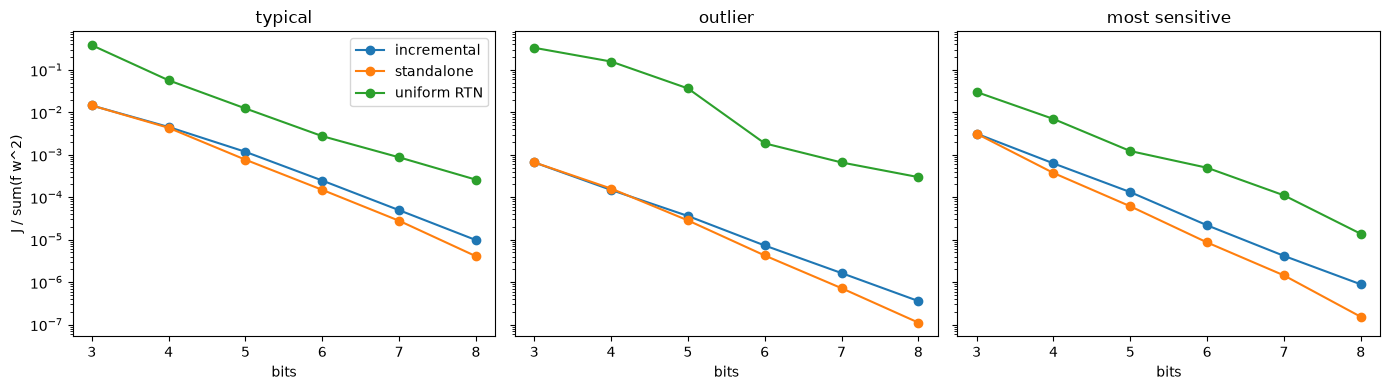

In [16]:
def relative_errors(rows: PreparedRows, label: str) -> dict[str, list[float]]:
    """Compute ``J / sum(f w^2)`` for incremental, standalone, and RTN codebooks at every bit-width.

    :param rows: Prepared rows of the study.
    :param label: Study label used to look up the fitted codebooks.
    :return: Relative errors keyed by method, one value per bit-width in ``bit_widths``.
    """
    energy: torch.Tensor = (rows.f_sorted * rows.w_sorted.square()).sum()
    return {
        "incremental": [
            (codebook_error(rows, incremental[label][b]).sum() / energy).item() for b in bit_widths
        ],
        "standalone": [
            (codebook_error(rows, standalone[label][b]).sum() / energy).item() for b in bit_widths
        ],
        "uniform RTN": [(uniform_rtn(rows, b)[1].sum() / energy).item() for b in bit_widths],
    }


nesting_rows: list[list[str | float]] = []
rtn_rows: list[list[str | float]] = []
fig, axes = plt.subplots(1, len(studies), figsize=(14, 4), sharey=True)
for ax, study in zip(axes, studies, strict=True):
    curves: dict[str, list[float]] = relative_errors(seeds[study.label][0], study.label)
    for method, values in curves.items():
        ax.plot(bit_widths, values, marker="o", label=method)
    ax.set_yscale("log")
    ax.set_title(f"{study.label}")
    ax.set_xlabel("bits")

    # Per-bit ratios: the price of nesting, and the advantage over uniform RTN.

    pairs_sa = zip(curves["incremental"], curves["standalone"], strict=True)
    pairs_rtn = zip(curves["uniform RTN"], curves["incremental"], strict=True)
    nesting_rows.append([study.label, *(a / s for a, s in pairs_sa)])
    rtn_rows.append([study.label, *(r / a for r, a in pairs_rtn)])
bit_headers: list[str] = [f"{b} bits" for b in bit_widths]
print("J_IU / J_SA (price of nesting):")
print(tabulate(nesting_rows, headers=["study", *bit_headers], floatfmt=".3f"))
print("\nJ_RTN / J_IU (advantage over uniform round-to-nearest):")
print(tabulate(rtn_rows, headers=["study", *bit_headers], floatfmt=".1f"))
axes[0].set_ylabel("J / sum(f w^2)")
axes[0].legend()
fig.tight_layout()
plt.show()

### 9.2 Whole modules

Three rows are anecdotes, so the same comparison is repeated over every row of two modules: the typical `q_proj` of layer 14 and the `output_linear` that holds the model's worst outlier row. Every row is fitted at once, which exercises the batched code on 1,024 rows.

In [17]:
module_names: list[str] = [typical_module, f"model.layers.{outlier_layer}.{outlier_kind}"]
module_table: list[tuple[str, int, float, float, float, float, float]] = []
module_timings: list[tuple[str, int, float]] = []
for module_name in module_names:
    started = time.perf_counter()

    # All rows of the module at once: [d_out, d_in] weights and Fisher values.

    module_rows: PreparedRows = prepare_rows(
        targets[module_name].weight.float(), fisher[module_name]
    )
    module_iu: dict[int, Codebook] = quantize_incremental(module_rows, SEED_BITS, PARENT_BITS)
    module_sa: dict[int, Codebook] = quantize_standalone(module_rows, SEED_BITS, PARENT_BITS)

    # Sum J over rows and normalize by the module's total weighted energy: [d_out] -> scalar.

    energy = (module_rows.f_sorted * module_rows.w_sorted.square()).sum()
    for b in bit_widths:
        iu: float = (codebook_error(module_rows, module_iu[b]).sum() / energy).item()
        sa: float = (codebook_error(module_rows, module_sa[b]).sum() / energy).item()
        rtn: float = (uniform_rtn(module_rows, b)[1].sum() / energy).item()
        module_table.append((module_name, b, iu, sa, rtn, iu / sa, rtn / iu))
    module_timings.append(
        (module_name, module_rows.w_sorted.shape[0], time.perf_counter() - started)
    )
print(
    tabulate(
        module_table,
        headers=["module", "bits", "J_IU / E", "J_SA / E", "J_RTN / E", "IU / SA", "RTN / IU"],
        floatfmt=("", "", ".2e", ".2e", ".2e", ".3f", ".1f"),
    )
)
print()
print(tabulate(module_timings, headers=["module", "rows", "seconds"], floatfmt=".1f"))

module                                     bits    J_IU / E    J_SA / E    J_RTN / E    IU / SA    RTN / IU
---------------------------------------  ------  ----------  ----------  -----------  ---------  ----------
model.layers.14.self_attn.q_proj              3    6.63e-03    6.63e-03     7.67e-02      1.000        11.6
model.layers.14.self_attn.q_proj              4    1.64e-03    1.18e-03     1.64e-02      1.388        10.0
model.layers.14.self_attn.q_proj              5    3.60e-04    2.08e-04     3.94e-03      1.733        10.9
model.layers.14.self_attn.q_proj              6    7.69e-05    3.79e-05     9.23e-04      2.031        12.0
model.layers.14.self_attn.q_proj              7    1.62e-05    6.57e-06     2.28e-04      2.463        14.1
model.layers.14.self_attn.q_proj              8    3.18e-06    9.18e-07     5.68e-05      3.468        17.9
model.layers.2.shared_mlp.output_linear       3    1.48e-02    1.48e-02     4.19e+00      1.000       282.7
model.layers.2.shared_mlp.ou

#### Takeaways from the error curves

- **Non-uniform beats uniform by one to two orders of magnitude.** On whole modules, $J_{\mathrm{RTN}} / J_{\mathrm{IU}}$ is 10–18 on the near-Gaussian `q_proj` and 167–283 on the outlier-laden layer 2 `output_linear`.
- **The error falls by about 4 times per bit.** That is the $4^{-b}$ high-resolution law behind the Panter–Dite estimate in ADR 0006. On layer 14 `q_proj`, successive incremental-upscaling ratios are 4.0, 4.6, 4.7, 4.7, and 5.1. Standalone k-means falls faster at high bit-widths (5.5 to 7 times per bit), partly because bfloat16 rows contain a limited set of distinct values. With 256 centroids for 1,024 weights, many clusters represent a single exact value.
- **The price of nesting grows with the bit-width but stays small in absolute terms.** $J_{\mathrm{IU}} / J_{\mathrm{SA}}$ is 1 at the seed by construction, 1.15–1.39 at 4 bits, and 1.6–3.5 at 8 bits. At 8 bits, both errors are $10^{-6}$ to $10^{-5}$ of the Fisher-weighted energy, far below the 3-bit error. The gap is therefore expected to be invisible in perplexity, consistent with the paper's under-0.1-perplexity result. ADR 0004's evaluation has to confirm this. The gap that matters for answer quality is at 4 and 5 bits.
- **The batched implementation is fast enough for the whole model.** Seeding and upscaling all 1,024 rows of a module, plus six standalone fits, takes 1.6–3.0 s on the laptop GPU, so all 168 modules take a few minutes.

## 10. Ablation: why k-means++ and not a quantile initialization

Initializing Lloyd at quantiles of the Fisher mass is attractive because it is deterministic and needs no RNG. Section 4.2 shows why it is fragile on Granite: when a few entries hold most of a row's mass, the mass quantiles land on the same few weights. Identical starting centroids produce empty segments, which Lloyd can never repopulate. The cell below measures all three initializations on the same two modules. For each it reports the fraction of clusters that end up empty, and the standalone and incremental errors.

In [18]:
init_methods: tuple[InitMethod, ...] = ("fisher-quantile", "count-quantile", "kmeans++")
ablation_rows: list[tuple[str, str, float, float, float, float]] = []
for module_name in module_names:
    module_rows = prepare_rows(targets[module_name].weight.float(), fisher[module_name])
    energy = (module_rows.f_sorted * module_rows.w_sorted.square()).sum()
    for init in init_methods:
        # Standalone fits at the seed and parent bit-widths, plus the nested parent from this seed.

        seed_codebook = weighted_lloyd(module_rows, 2**SEED_BITS, init)[:2]
        parent_codebook = weighted_lloyd(module_rows, 2**PARENT_BITS, init)[:2]
        nested_parent = quantize_incremental(module_rows, SEED_BITS, PARENT_BITS, init)[PARENT_BITS]

        # Empty clusters at 8 bits: [R, K + 1] borders -> [R, K] sizes -> fraction of zeros.

        sizes: torch.Tensor = parent_codebook[1][:, 1:] - parent_codebook[1][:, :-1]
        empty: float = 100 * (sizes == 0).double().mean().item()
        sa3: float = (codebook_error(module_rows, seed_codebook).sum() / energy).item()
        sa8: float = (codebook_error(module_rows, parent_codebook).sum() / energy).item()
        iu8: float = (codebook_error(module_rows, nested_parent).sum() / energy).item()
        ablation_rows.append((module_name, init, empty, sa3, sa8, iu8))
print(
    tabulate(
        ablation_rows,
        headers=[
            "module",
            "init",
            "empty clusters at 8 bits (%)",
            "SA J / E at 3 bits",
            "SA J / E at 8 bits",
            "IU J / E at 8 bits",
        ],
        floatfmt=("", "", ".1f", ".2e", ".2e", ".2e"),
    )
)

module                                   init               empty clusters at 8 bits (%)    SA J / E at 3 bits    SA J / E at 8 bits    IU J / E at 8 bits
---------------------------------------  ---------------  ------------------------------  --------------------  --------------------  --------------------
model.layers.14.self_attn.q_proj         fisher-quantile                            68.3              1.75e-02              3.77e-04              1.03e-05
model.layers.14.self_attn.q_proj         count-quantile                              0.1              1.33e-02              2.47e-04              3.28e-06
model.layers.14.self_attn.q_proj         kmeans++                                    0.0              6.63e-03              9.18e-07              3.18e-06
model.layers.2.shared_mlp.output_linear  fisher-quantile                            88.6              1.76e-02              6.76e-03              1.38e-05
model.layers.2.shared_mlp.output_linear  count-quantile               

#### Takeaways from the ablation

- **The Fisher-quantile initialization collapses.** It leaves 68% and 89% of the 8-bit clusters empty, and the 8-bit standalone error is about 410 and 940 times worse than with k-means++. Even the 3-bit seed is 2.6 and 1.2 times worse, and every upscaled level inherits it: the 8-bit incremental error from that seed is 3.2 and 1.2 times worse.
- **Count quantiles avoid the collapse but are still poor standalone.** No clusters are empty, but the 8-bit standalone error is still 270 and 33 times worse than k-means++, because the centroids ignore where the sensitivity lives.
- **Incremental upscaling depends on its seed.** From a count-quantile seed, the 8-bit parent is almost as good as from k-means++ (about 3.3e-6 versus 3.2e-6). The exact splits repair a mediocre seed well, but they cannot repair a collapsed one.

This is why ADR 0003 specifies weighted greedy k-means++ for the seed.

## 11. Next steps

- Move `prepare_rows`, the initializations, `weighted_lloyd`, `split_all_segments`, and `estimate_fisher` into `src/anyprec` with tests, per ADR 0001. The section 8 properties become property-based tests on a tiny random Granite.
- Quantize all 168 modules and write the any-precision artifact (ADR 0005).
- Measure perplexity, KL, and top-1 agreement at 3 to 8 bits (ADR 0004), and check whether the nesting gap at 4 and 5 bits is visible.
- Probe SwiGLU channel 1603 of layer 2 on chat-formatted prompts, to see whether a weight that is irrelevant on C4 stays irrelevant on the instruction-tuned model's real inputs.